# Exploring the LUNA16 Dataset

This notebook explores the structure and properties of the LUNA16 dataset before implementing the preprocessing pipeline.

**Goals**

- Load a CT volume.
- Study image metadata.
- Understand voxel spacing.
- Visualize CT slices.
- Prepare for patch extraction.

In [14]:
from pathlib import Path

import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt

# Project paths
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "LUNA16"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

# Create output directory if it does not exist
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Figures directory:", FIGURES_DIR)

Project root: /mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn
Data directory: /mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/data/raw/LUNA16
Figures directory: /mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/outputs/figures


## Step 1 — Locate CT Volumes

The LUNA16 dataset contains CT scans stored as MetaImage files (`.mhd` and `.raw`).

In this step we search for all available CT volumes.

In [15]:
# Find all LUNA16 CT header files
mhd_files = sorted(DATA_DIR.rglob("*.mhd"))

print("Number of .mhd files:", len(mhd_files))

for path in mhd_files[:5]:
    print(path)

Number of .mhd files: 356
/mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/data/raw/LUNA16/data-unversioned/part2/luna/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260.mhd
/mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/data/raw/LUNA16/data-unversioned/part2/luna/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492.mhd
/mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/data/raw/LUNA16/data-unversioned/part2/luna/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524522225658609808059.mhd
/mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/data/raw/LUNA16/data-unversioned/part2/luna/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.111172165674661221381920536987.mhd
/mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/data/raw/LUNA16/data-unversioned/part2/luna/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.122763913896761494371822656720.mhd


## Step 2 — Load the First CT Scan

We load one CT volume using SimpleITK and inspect its metadata.

In [16]:
# Select the first CT scan
ct_path = mhd_files[0]

# Read CT image
image = sitk.ReadImage(str(ct_path))

# Convert to NumPy array
ct_array = sitk.GetArrayFromImage(image)

print("CT path:", ct_path)
print("SimpleITK size (x, y, z):", image.GetSize())
print("NumPy shape (z, y, x):", ct_array.shape)
print("Spacing (x, y, z):", image.GetSpacing())
print("Origin (x, y, z):", image.GetOrigin())
print("Direction:", image.GetDirection())
print("Min HU:", ct_array.min())
print("Max HU:", ct_array.max())
print("Mean HU:", ct_array.mean())

CT path: /mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/data/raw/LUNA16/data-unversioned/part2/luna/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260.mhd
SimpleITK size (x, y, z): (512, 512, 121)
NumPy shape (z, y, x): (121, 512, 512)
Spacing (x, y, z): (0.7617189884185791, 0.7617189884185791, 2.5)
Origin (x, y, z): (-198.100006, -195.0, -335.209991)
Direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)
Min HU: -3024
Max HU: 2103
Mean HU: -1035.6235232077354


## Step 3 — Visualize an Axial Slice

The CT volume is converted into a NumPy array.

The middle axial slice is displayed using the lung window.

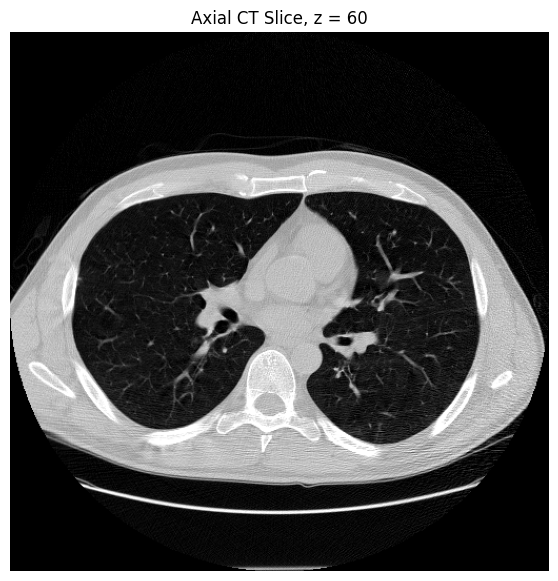

Saved figure: /mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/outputs/figures/first_ct_slice.png


In [17]:
# Select middle axial slice
z_index = ct_array.shape[0] // 2
slice_2d = ct_array[z_index]

# Output file
output_path = FIGURES_DIR / "first_ct_slice.png"

# Save CT slice
plt.figure(figsize=(7, 7))
plt.imshow(slice_2d, cmap="gray", vmin=-1000, vmax=400)
plt.title(f"Axial CT Slice, z = {z_index}")
plt.axis("off")
plt.savefig(output_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", output_path)

# Step 4 — Understanding the CT Volume

A CT scan is a three-dimensional volume.

After converting the image to a NumPy array, the dimensions are ordered as:

(z, y, x)

where:

- z — slice index
- y — image row
- x — image column

In [18]:
# Explore CT volume dimensions

num_slices = ct_array.shape[0]
height = ct_array.shape[1]
width = ct_array.shape[2]

print(f"Number of slices : {num_slices}")
print(f"Slice height     : {height}")
print(f"Slice width      : {width}")

print()
print("Array indexing order:")
print("ct_array[z, y, x]")

Number of slices : 121
Slice height     : 512
Slice width      : 512

Array indexing order:
ct_array[z, y, x]


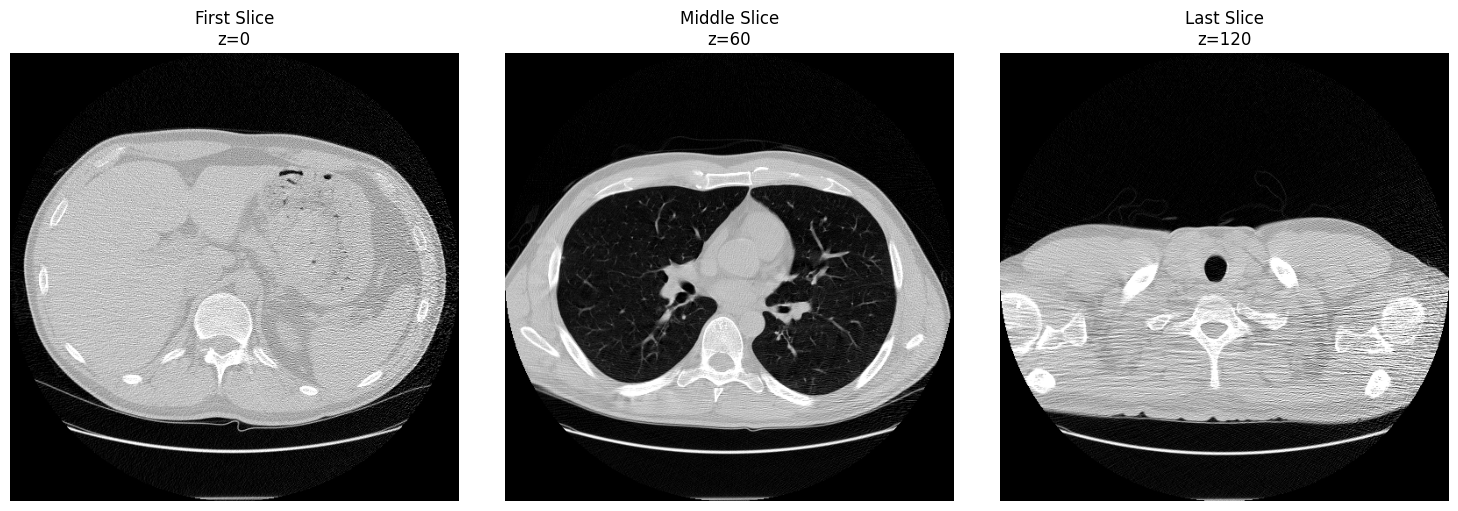

Saved: /mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/outputs/figures/three_axial_slices.png


In [19]:
# Select representative slices

z_first = 0
z_middle = ct_array.shape[0] // 2
z_last = ct_array.shape[0] - 1

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(ct_array[z_first], cmap="gray", vmin=-1000, vmax=400)
axes[0].set_title(f"First Slice\nz={z_first}")
axes[0].axis("off")

axes[1].imshow(ct_array[z_middle], cmap="gray", vmin=-1000, vmax=400)
axes[1].set_title(f"Middle Slice\nz={z_middle}")
axes[1].axis("off")

axes[2].imshow(ct_array[z_last], cmap="gray", vmin=-1000, vmax=400)
axes[2].set_title(f"Last Slice\nz={z_last}")
axes[2].axis("off")

plt.tight_layout()

output_path = FIGURES_DIR / "three_axial_slices.png"

plt.savefig(output_path, dpi=200)

plt.show()

print("Saved:", output_path)

## Step 5 — Visualize Orthogonal Views

A CT scan is a three-dimensional volume.

Different anatomical planes can be obtained by fixing one coordinate:

- Axial: fix **z**
- Coronal: fix **y**
- Sagittal: fix **x**

These three views are commonly used by radiologists.

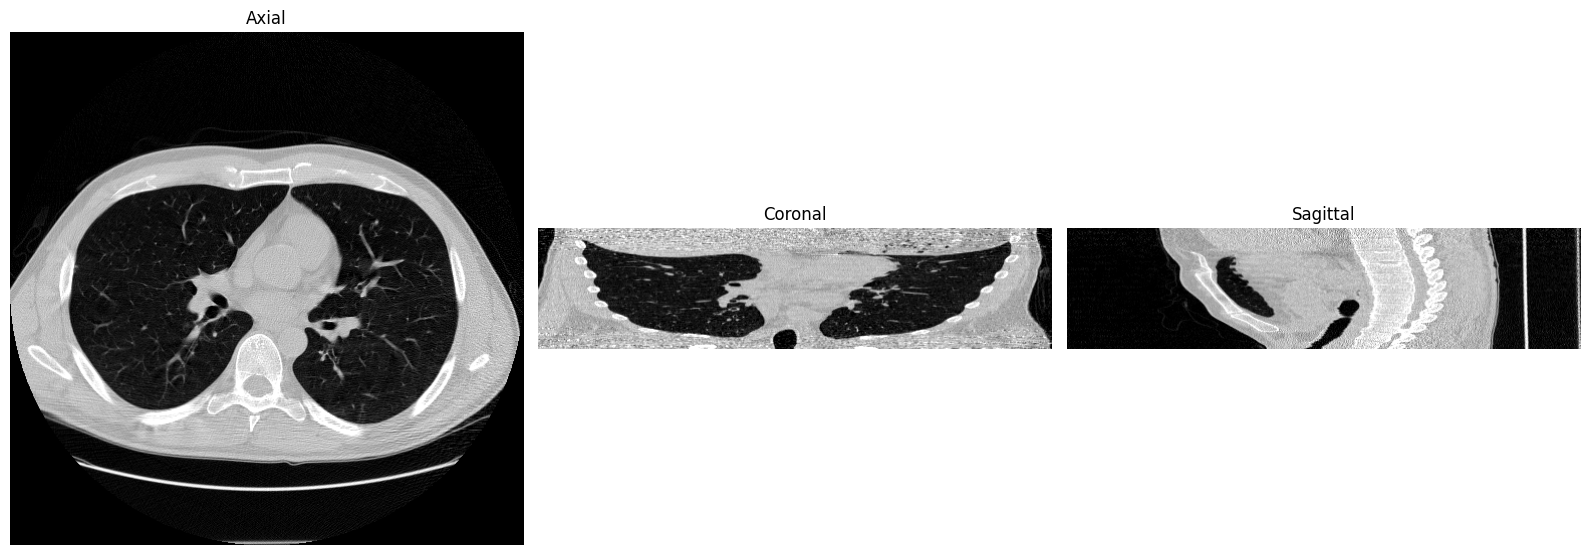

Saved figure: /mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/outputs/figures/orthogonal_views.png


In [20]:
# Select middle indices
z = ct_array.shape[0] // 2
y = ct_array.shape[1] // 2
x = ct_array.shape[2] // 2

# Extract orthogonal slices
axial = ct_array[z, :, :]
coronal = ct_array[:, y, :]
sagittal = ct_array[:, :, x]

# Display slices
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

axes[0].imshow(axial, cmap="gray", vmin=-1000, vmax=400)
axes[0].set_title("Axial")
axes[0].axis("off")

axes[1].imshow(coronal, cmap="gray", vmin=-1000, vmax=400)
axes[1].set_title("Coronal")
axes[1].axis("off")

axes[2].imshow(sagittal, cmap="gray", vmin=-1000, vmax=400)
axes[2].set_title("Sagittal")
axes[2].axis("off")

plt.tight_layout()

output_path = FIGURES_DIR / "orthogonal_views.png"

plt.savefig(output_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure: {output_path}")

## Step 6 — Explore Hounsfield Units

Each voxel in a CT scan stores a physical density value measured in Hounsfield Units (HU).

In this section we inspect the HU distribution of the entire CT volume.

In [21]:
# Flatten the CT volume into one dimension
hu_values = ct_array.ravel()

print(f"Number of voxels : {hu_values.size:,}")
print(f"Minimum HU       : {hu_values.min():.0f}")
print(f"Maximum HU       : {hu_values.max():.0f}")
print(f"Mean HU          : {hu_values.mean():.2f}")
print(f"Median HU        : {np.median(hu_values):.2f}")
print(f"Standard deviation: {hu_values.std():.2f}")

Number of voxels : 31,719,424
Minimum HU       : -3024
Maximum HU       : 2103
Mean HU          : -1035.62
Median HU        : -913.00
Standard deviation: 1126.60


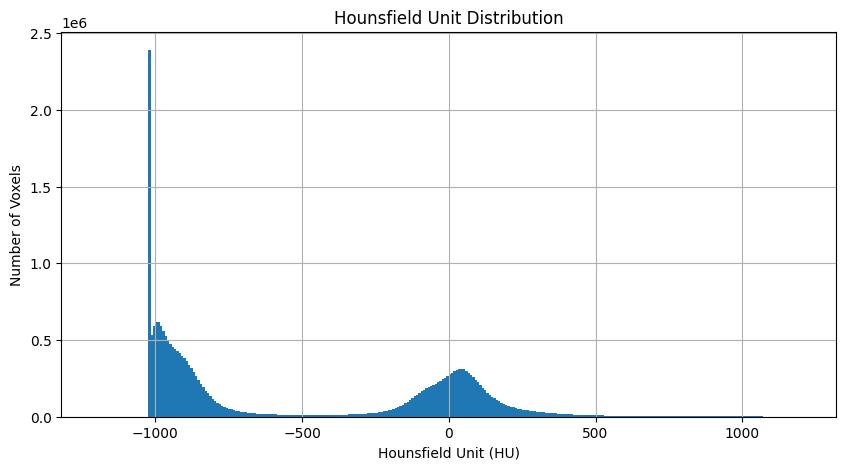

Saved figure: /mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/outputs/figures/hu_histogram.png


In [22]:
# Plot HU histogram
plt.figure(figsize=(10, 5))

plt.hist(
    hu_values,
    bins=300,
    range=(-1200, 1200)
)

plt.title("Hounsfield Unit Distribution")
plt.xlabel("Hounsfield Unit (HU)")
plt.ylabel("Number of Voxels")

plt.grid(True)

output_path = FIGURES_DIR / "hu_histogram.png"

plt.savefig(output_path, dpi=200, bbox_inches="tight")

plt.show()

print(f"Saved figure: {output_path}")

## Step 7 — CT Windowing

A CT scan contains a very large range of Hounsfield Units.

Windowing maps a selected HU range to grayscale values, allowing different anatomical structures to become visible.

In this section we compare different CT windows.

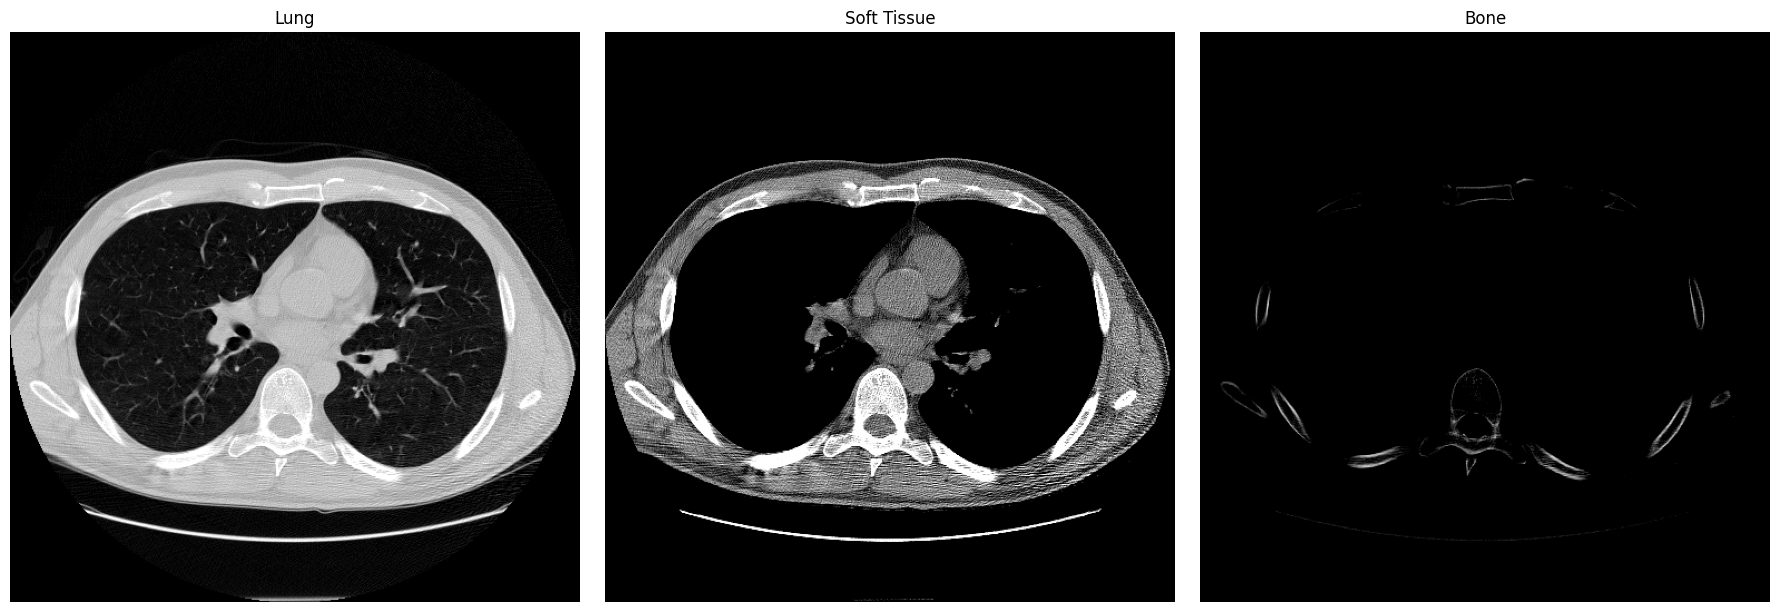

Saved figure: /mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/outputs/figures/ct_windows.png


In [23]:
# Select middle slice
z = ct_array.shape[0] // 2
slice_2d = ct_array[z]

# Define commonly used CT windows
windows = [
    ("Lung", -1000, 400),
    ("Soft Tissue", -150, 250),
    ("Bone", 300, 1500),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (title, vmin, vmax) in zip(axes, windows):

    ax.imshow(
        slice_2d,
        cmap="gray",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()

output_path = FIGURES_DIR / "ct_windows.png"

plt.savefig(output_path, dpi=200, bbox_inches="tight")

plt.show()

print(f"Saved figure: {output_path}")

# Step 8 — Explore LUNA16 Annotations

The LUNA16 dataset provides annotations created by radiologists.

Each annotation contains:

- CT scan identifier
- Nodule center in world coordinates (millimeters)
- Nodule diameter (millimeters)

Our goal is to understand how these coordinates relate to the CT volume.

In [24]:
import pandas as pd

# Load radiologist annotations
annotations_path = DATA_DIR / "data-unversioned" / "part2" / "luna" / "annotations.csv"

annotations = pd.read_csv(annotations_path)

print("Number of annotated nodules:", len(annotations))

annotations.head()

Number of annotated nodules: 1186


,seriesuid,coordX,coordY,coordZ,diameter_mm
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-128.699421,-175.319272,-298.387506,5.651471
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.783651,-211.925149,-227.121250,4.224708
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,69.639017,-140.944586,876.374496,5.786348
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,-24.013824,192.102405,-391.081276,8.143262
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,2.441547,172.464881,-405.493732,18.545150


## Step 9 — Convert World Coordinates to Voxel Coordinates

LUNA16 annotations store nodule centers in world coordinates measured in millimeters.

However, NumPy arrays use voxel indices:

`ct_array[z, y, x]`

So we need to convert:

world coordinates `(x, y, z)` → voxel coordinates `(x, y, z)` → NumPy indexing `(z, y, x)`.

In [25]:
# Select first annotated nodule
row = annotations.iloc[0]

series_uid = row["seriesuid"]
world_coord = np.array([row["coordX"], row["coordY"], row["coordZ"]], dtype=np.float32)
diameter_mm = row["diameter_mm"]

print("Series UID:", series_uid)
print("World coordinate (x, y, z) in mm:", world_coord)
print("Diameter (mm):", diameter_mm)

Series UID: 1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860
World coordinate (x, y, z) in mm: [-128.69942 -175.31927 -298.3875 ]
Diameter (mm): 5.651470635


In [51]:
# Cell 15 — keep only annotations for available CT scans

available_series_uids = {p.stem for p in mhd_files}

available_annotations = filter_available_scans(
    annotations,
    available_series_uids,
)

print("Available annotations:", len(available_annotations))

print("Available CT scans:", len(available_series_uids))
print("All annotations:", len(annotations))
print("Available annotations:", len(available_annotations))

available_annotations.head()

print('-'*33)

# Keep only candidates for available CT scans

available_candidates = filter_available_scans(
    candidates,
    available_series_uids,
)

print("Available candidates:", len(available_candidates))

available_candidates.head()

Available annotations: 368
Available CT scans: 267
All annotations: 1186
Available annotations: 368
---------------------------------
Available candidates: 166001


,seriesuid,coordX,coordY,coordZ,class
3038,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,-76.62,156.53,-529.43,0
3039,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,120.13,160.73,-404.68,0
3040,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,94.23,171.24,-392.76,0
3041,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,74.62,190.84,-534.34,0
3042,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,-6.60,189.44,-469.16,0


In [52]:
# Count positive and negative candidates

print(candidates["class"].value_counts())

print()

print(available_candidates["class"].value_counts())

class
0    549714
1      1351
Name: count, dtype: int64

class
0    165568
1       433
Name: count, dtype: int64


In [53]:
# Show one positive candidate

positive_candidates = available_candidates[
    available_candidates["class"] == 1
]

print("Positive candidates:", len(positive_candidates))

positive_candidates.head()

Positive candidates: 433


,seriesuid,coordX,coordY,coordZ,class
3050,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,89.320000,190.840000,-516.820000,1
3052,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,94.930000,153.030000,-429.910000,1
3080,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,8.800000,174.740000,-401.870000,1
3223,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,88.872494,197.683673,-514.393956,1
3285,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,2.019566,172.593068,-405.052893,1


In [54]:
# Select the first positive candidate

candidate = positive_candidates.iloc[0]

print(candidate)

seriesuid    1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...
coordX                                                   89.32
coordY                                                  190.84
coordZ                                                 -516.82
class                                                        1
Name: 3050, dtype: object


In [55]:
# Find the corresponding annotation

candidate_uid = candidate["seriesuid"]

matching_annotations = available_annotations[
    available_annotations["seriesuid"] == candidate_uid
]

print("Number of annotations:", len(matching_annotations))

matching_annotations

Number of annotations: 4


,seriesuid,coordX,coordY,coordZ,diameter_mm
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,-24.013824,192.102405,-391.081276,8.143262
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,2.441547,172.464881,-405.493732,18.545150
5,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,90.931713,149.027266,-426.544715,18.208570
6,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,89.540769,196.405159,-515.073322,16.381276


In [32]:
# Cell 16 — select the first available annotated nodule

row = available_annotations.iloc[0]

series_uid = row["seriesuid"]
world_coord = np.array(
    [row["coordX"], row["coordY"], row["coordZ"]],
    dtype=np.float32
)

diameter_mm = row["diameter_mm"]

print("Series UID:", series_uid)
print("World coordinate:", world_coord)
print("Diameter (mm):", diameter_mm)

NameError: name 'available_annotations' is not defined

In [33]:
# Cell 17 — Find the corresponding CT scan

matching_files = [p for p in mhd_files if p.stem == series_uid]

print("Matching files:", len(matching_files))

ct_path = matching_files[0]

print(ct_path)

Matching files: 0


IndexError: list index out of range

In [34]:
# Cell 18 — Load selected CT scan and inspect metadata

image = sitk.ReadImage(str(ct_path))
ct_array = sitk.GetArrayFromImage(image)

origin = np.array(image.GetOrigin(), dtype=np.float32)
spacing = np.array(image.GetSpacing(), dtype=np.float32)

print("Image size (x, y, z):", image.GetSize())
print("NumPy shape (z, y, x):", ct_array.shape)
print("Origin (x, y, z):", origin)
print("Spacing (x, y, z):", spacing)

Image size (x, y, z): (512, 512, 121)
NumPy shape (z, y, x): (121, 512, 512)
Origin (x, y, z): [-198.1  -195.   -335.21]
Spacing (x, y, z): [0.761719 0.761719 2.5     ]


In [35]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.preprocessing import world_to_voxel, normalize_hu
from src.data.patch_extractor import extract_patch

print("Imports successful!")

Imports successful!


In [36]:
# Cell 19 — Convert world coordinates to voxel coordinates

from src.data.preprocessing import world_to_voxel, normalize_hu

# voxel_coord_xyz = np.round((world_coord - origin) / spacing).astype(int)
voxel_coord_xyz = world_to_voxel(
    world_coord=world_coord,
    origin=origin,
    spacing=spacing,
)

voxel_x = voxel_coord_xyz[0]
voxel_y = voxel_coord_xyz[1]
voxel_z = voxel_coord_xyz[2]

print("World coordinate (x, y, z):", world_coord)
print("Voxel coordinate (x, y, z):", voxel_coord_xyz)
print("NumPy index (z, y, x):", (voxel_z, voxel_y, voxel_x))

print("HU value at nodule center:", ct_array[voxel_z, voxel_y, voxel_x])

World coordinate (x, y, z): [-128.69942 -175.31927 -298.3875 ]
Voxel coordinate (x, y, z): [91 26 15]
NumPy index (z, y, x): (np.int64(15), np.int64(26), np.int64(91))
HU value at nodule center: -3024


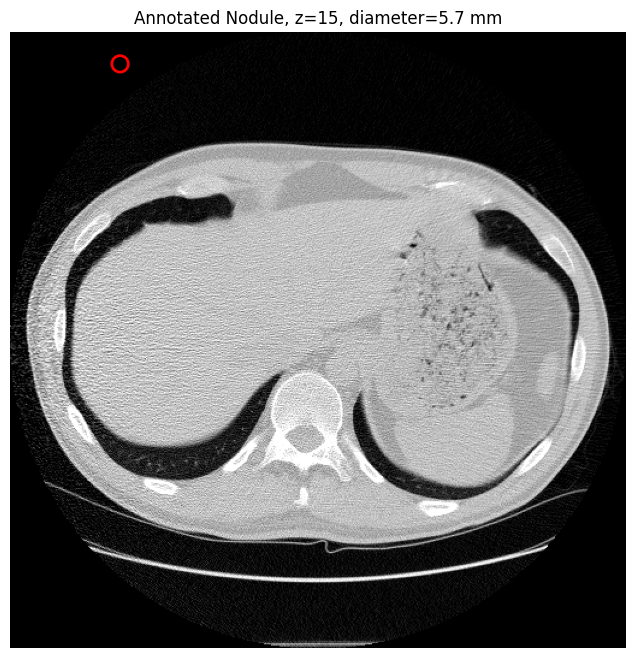

Saved figure: /mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/outputs/figures/first_annotated_nodule.png


In [37]:
# Cell 20 — Visualize the annotated nodule on axial slice

slice_2d = ct_array[voxel_z]

plt.figure(figsize=(8, 8))

plt.imshow(
    slice_2d,
    cmap="gray",
    vmin=-1000,
    vmax=400
)

# Mark nodule center
plt.scatter(
    voxel_x,
    voxel_y,
    s=140,
    facecolors="none",
    edgecolors="red",
    linewidths=2
)

plt.title(f"Annotated Nodule, z={voxel_z}, diameter={diameter_mm:.1f} mm")
plt.axis("off")

output_path = FIGURES_DIR / "first_annotated_nodule.png"

plt.savefig(output_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", output_path)

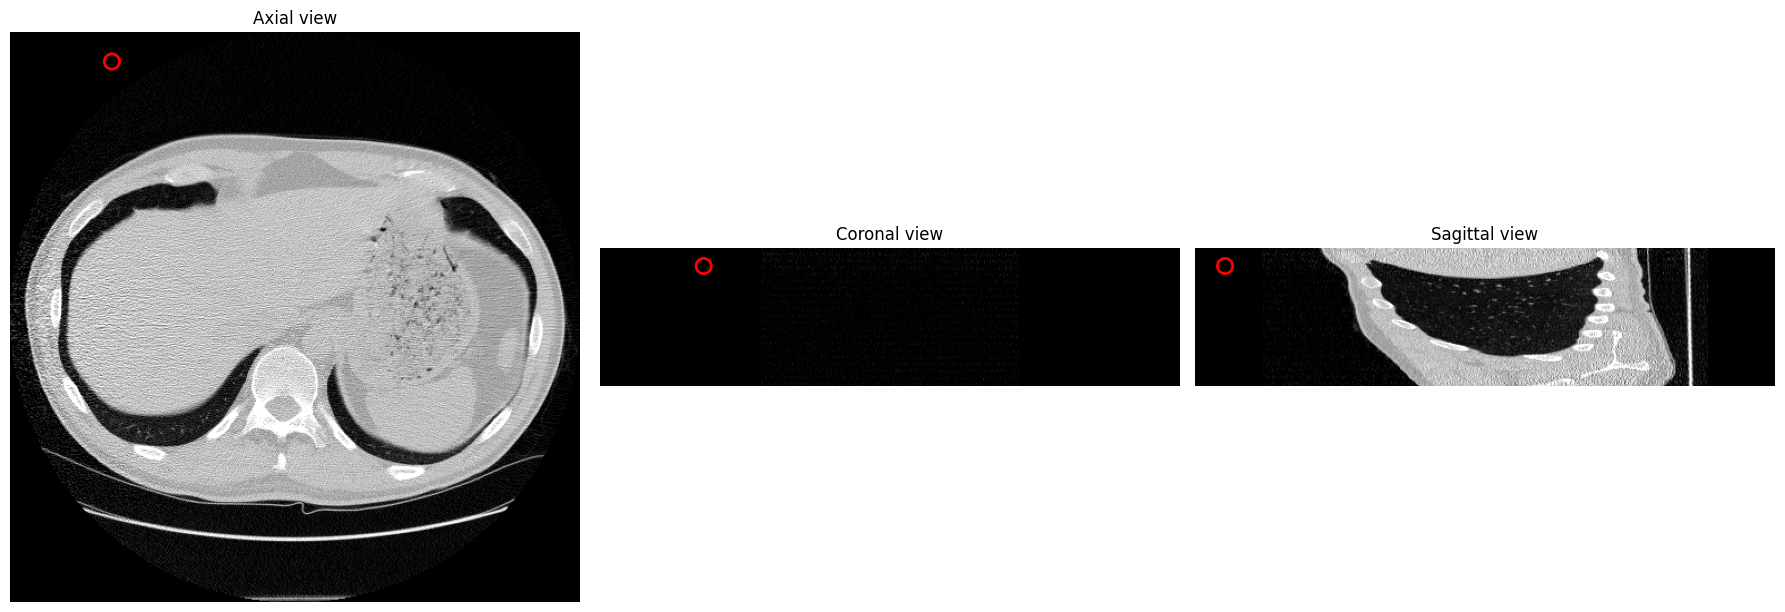

Saved figure: /mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/outputs/figures/annotated_nodule_orthogonal_views.png


In [38]:
# Cell 21 — Visualize annotated nodule in three orthogonal views

axial = ct_array[voxel_z, :, :]
coronal = ct_array[:, voxel_y, :]
sagittal = ct_array[:, :, voxel_x]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Axial view: x-y plane
axes[0].imshow(axial, cmap="gray", vmin=-1000, vmax=400)
axes[0].scatter(voxel_x, voxel_y, s=120, facecolors="none", edgecolors="red", linewidths=2)
axes[0].set_title("Axial view")
axes[0].axis("off")

# Coronal view: x-z plane
axes[1].imshow(coronal, cmap="gray", vmin=-1000, vmax=400)
axes[1].scatter(voxel_x, voxel_z, s=120, facecolors="none", edgecolors="red", linewidths=2)
axes[1].set_title("Coronal view")
axes[1].axis("off")

# Sagittal view: y-z plane
axes[2].imshow(sagittal, cmap="gray", vmin=-1000, vmax=400)
axes[2].scatter(voxel_y, voxel_z, s=120, facecolors="none", edgecolors="red", linewidths=2)
axes[2].set_title("Sagittal view")
axes[2].axis("off")

plt.tight_layout()

output_path = FIGURES_DIR / "annotated_nodule_orthogonal_views.png"
plt.savefig(output_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", output_path)

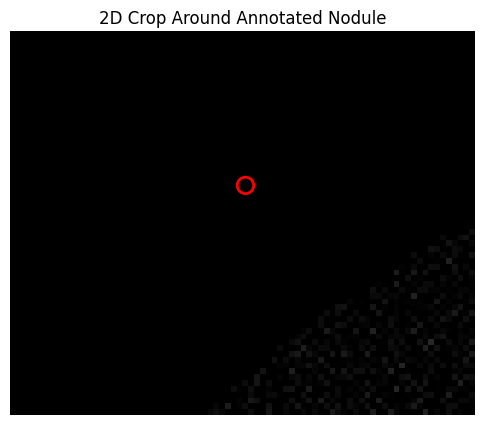

Saved figure: /mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/outputs/figures/annotated_nodule_2d_crop.png


In [39]:
# Cell 22 — Crop a 2D region around the annotated nodule

crop_radius = 40

y_min = max(voxel_y - crop_radius, 0)
y_max = min(voxel_y + crop_radius, ct_array.shape[1])

x_min = max(voxel_x - crop_radius, 0)
x_max = min(voxel_x + crop_radius, ct_array.shape[2])

nodule_crop = ct_array[voxel_z, y_min:y_max, x_min:x_max]

plt.figure(figsize=(6, 6))
plt.imshow(nodule_crop, cmap="gray", vmin=-1000, vmax=400)

# Mark nodule center inside crop
plt.scatter(
    voxel_x - x_min,
    voxel_y - y_min,
    s=140,
    facecolors="none",
    edgecolors="red",
    linewidths=2
)

plt.title("2D Crop Around Annotated Nodule")
plt.axis("off")

output_path = FIGURES_DIR / "annotated_nodule_2d_crop.png"
plt.savefig(output_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", output_path)

In [40]:
# Cell 23 — Extract a 3D patch around the annotated nodule

patch_size = 64
half_size = patch_size // 2

z_min = max(voxel_z - half_size, 0)
z_max = min(voxel_z + half_size, ct_array.shape[0])

y_min = max(voxel_y - half_size, 0)
y_max = min(voxel_y + half_size, ct_array.shape[1])

x_min = max(voxel_x - half_size, 0)
x_max = min(voxel_x + half_size, ct_array.shape[2])

patch_3d = ct_array[z_min:z_max, y_min:y_max, x_min:x_max]

print("3D patch shape:", patch_3d.shape)
print("Patch HU min:", patch_3d.min())
print("Patch HU max:", patch_3d.max())
print("Patch HU mean:", patch_3d.mean())

3D patch shape: (47, 58, 64)
Patch HU min: -3024
Patch HU max: -431
Patch HU mean: -2841.7671152787966


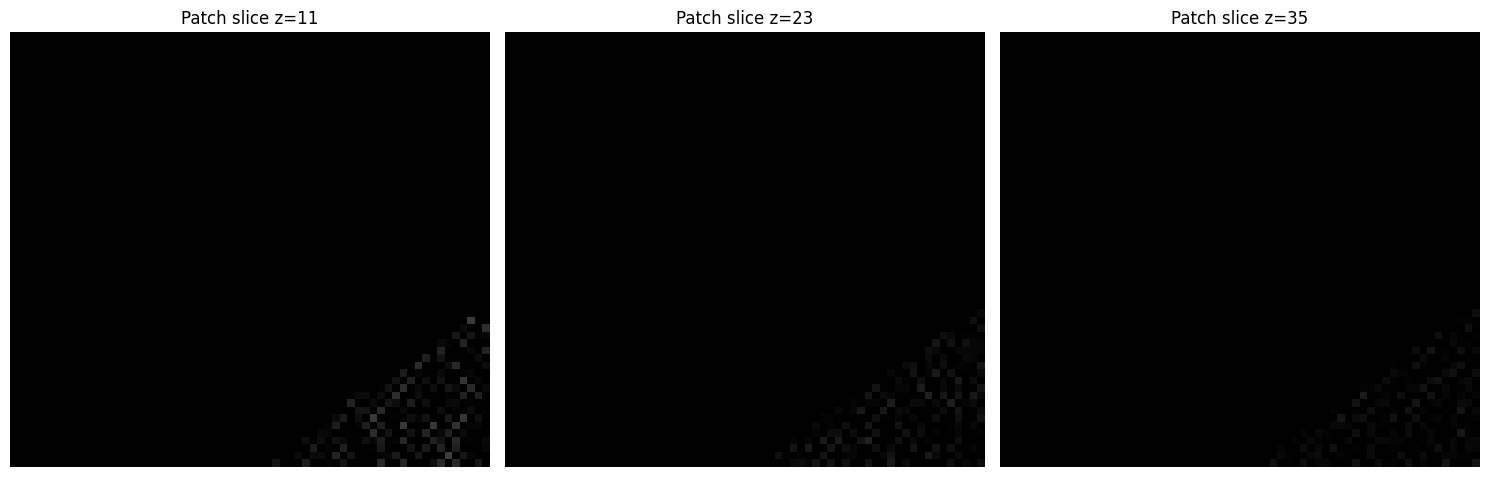

Saved figure: /mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/outputs/figures/first_3d_patch_slices.png


In [41]:
# Cell 24 — Visualize several slices from the 3D patch

slice_indices = [
    patch_3d.shape[0] // 4,
    patch_3d.shape[0] // 2,
    3 * patch_3d.shape[0] // 4,
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, idx in zip(axes, slice_indices):
    ax.imshow(
        patch_3d[idx],
        cmap="gray",
        vmin=-1000,
        vmax=400
    )
    ax.set_title(f"Patch slice z={idx}")
    ax.axis("off")

plt.tight_layout()

output_path = FIGURES_DIR / "first_3d_patch_slices.png"
plt.savefig(output_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", output_path)

In [42]:
# Cell 25 — Clip and normalize the 3D patch

from src.data.preprocessing import normalize_hu

hu_min = -1000
hu_max = 400

# Clip extreme HU values
patch_normalized = normalize_hu(patch_3d)

print("Original patch min/max:", patch_3d.min(), patch_3d.max())
print("Normalized patch min/max:", patch_normalized.min(), patch_normalized.max())
print("Normalized patch shape:", patch_normalized.shape)

Original patch min/max: -3024 -431
Normalized patch min/max: 0.0 0.40642858
Normalized patch shape: (47, 58, 64)


In [43]:
# Cell 26 — Save normalized 3D patch

PATCHES_DIR = PROJECT_ROOT / "data" / "patches"
PATCHES_DIR.mkdir(parents=True, exist_ok=True)

patch_path = PATCHES_DIR / "first_positive_nodule_patch.npy"

np.save(patch_path, patch_normalized.astype(np.float32))

print("Saved patch:", patch_path)
print("Saved shape:", patch_normalized.shape)
print("Saved dtype:", patch_normalized.astype(np.float32).dtype)

Saved patch: /mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/data/patches/first_positive_nodule_patch.npy
Saved shape: (47, 58, 64)
Saved dtype: float32


In [44]:
# Cell 28 — Test the reusable function

patch = extract_patch(
    ct_array,
    voxel_x,
    voxel_y,
    voxel_z,
    patch_size=64
)

print("Patch shape:", patch.shape)

Patch shape: (47, 58, 64)


In [45]:
# Test import from project source code

import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.patch_extractor import extract_patch

print("extract_patch imported successfully")

extract_patch imported successfully


In [46]:
# Test extract_patch() from src

patch = extract_patch(
    volume=ct_array,
    voxel_x=voxel_x,
    voxel_y=voxel_y,
    voxel_z=voxel_z,
    patch_size=64,
)

print("Patch shape:", patch.shape)
print("Patch dtype:", patch.dtype)
print("Min HU:", patch.min())
print("Max HU:", patch.max())

Patch shape: (47, 58, 64)
Patch dtype: int16
Min HU: -3024
Max HU: -431


In [47]:
# Import world_to_voxel from project source code

from src.data.preprocessing import world_to_voxel

voxel_coord_xyz = world_to_voxel(
    world_coord=world_coord,
    origin=origin,
    spacing=spacing,
)

print("Voxel coordinate (x, y, z):", voxel_coord_xyz)

Voxel coordinate (x, y, z): [91 26 15]


In [48]:
from src.data.candidate_loader import (
    load_csv,
    filter_available_scans,
)

# from src.data.candidate_loader import (
#     load_annotations,
#     load_candidates,
#     filter_available_scans,
# )

In [49]:
# annotations = load_annotations(
#     DATA_DIR / "data-unversioned" / "part2" / "luna" / "annotations.csv"
# )

# candidates = load_candidates(
#     DATA_DIR / "data-unversioned" / "part2" / "luna" / "candidates.csv"
# )

annotations = load_csv(
    DATA_DIR / "data-unversioned" / "part2" / "luna" / "annotations.csv"
)

candidates = load_csv(
    DATA_DIR / "data-unversioned" / "part2" / "luna" / "candidates.csv"
)

print("Annotations:", len(annotations))
print("Candidates :", len(candidates))

Annotations: 1186
Candidates : 551065


In [50]:
## Testing LunaDataset

from src.data.luna_dataset import LunaDataset

dataset = LunaDataset(
    annotations_path=DATA_DIR / "data-unversioned" / "part2" / "luna" / "annotations.csv",
    available_series_uids=available_series_uids,
)

print("Dataset size:", len(dataset))

Dataset size: 368
